In [2]:
!pip install xgboost lightgbm catboost --quiet


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

# Dark theme
plt.style.use("dark_background")
sns.set_palette("bright")


In [4]:
# Load merged dataset with pipeline features
df_main = pd.read_csv("/content/weekly_features_engineered_v2.csv")

print("Dataset shape:", df_main.shape)
print("Columns:", df_main.shape[1])
df_main.head()

Dataset shape: (4758, 63)
Columns: 63


,Date,Vegetable,Price,Month,Quarter,Price_Lag_1,Price_Lag_2,Price_Lag_3,Price_Lag_4,Price_Lag_8,...,Vegetable_Code,Wholesale_Price,Wholesale_Lag1,Wholesale_Lag2,Wholesale_Rolling_Mean4,USD_LKR,ExchangeRate_Change,avg_flood_prob,avg_drought_prob,avg_precipitation
0,2010-01-11,Bitter Gourd,116.13,1,1,114.12,0.00,0.00,0.00,0.0,...,0,58.6,266.0,300.0,226.150,114.25,-0.13,0.008776,0.719184,0.0
1,2010-01-18,Bitter Gourd,120.54,1,1,116.13,114.12,0.00,0.00,0.0,...,0,58.6,260.0,316.0,228.150,114.35,0.09,0.000000,0.722857,0.0
2,2010-01-25,Bitter Gourd,115.14,1,1,120.54,116.13,114.12,0.00,0.0,...,0,58.6,272.0,330.0,245.150,114.65,0.26,0.012449,0.719388,0.0
3,2010-02-01,Bitter Gourd,111.50,2,1,115.14,120.54,116.13,114.12,0.0,...,0,54.3,338.0,406.0,264.575,114.70,0.04,0.002449,0.986531,0.0
4,2010-02-08,Bitter Gourd,116.15,2,1,111.50,115.14,120.54,116.13,0.0,...,0,50.0,386.0,426.0,273.500,114.70,0.00,0.000000,0.993265,0.0


In [5]:
df_main.info()
TARGET = "Price"

# Verify new pipeline features are present
pipeline_features = ['Wholesale_Price','Wholesale_Lag1','Wholesale_Lag2',
                     'Wholesale_Rolling_Mean4','USD_LKR','ExchangeRate_Change',
                     'avg_flood_prob','avg_drought_prob','avg_precipitation']
print("\nPipeline features present:")
for f in pipeline_features:
    print(f"  {f}: {'✓' if f in df_main.columns else '✗ MISSING'}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4758 entries, 0 to 4757
Data columns (total 63 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      4758 non-null   object 
 1   Vegetable                 4758 non-null   object 
 2   Price                     4758 non-null   float64
 3   Month                     4758 non-null   int64  
 4   Quarter                   4758 non-null   int64  
 5   Price_Lag_1               4758 non-null   float64
 6   Price_Lag_2               4758 non-null   float64
 7   Price_Lag_3               4758 non-null   float64
 8   Price_Lag_4               4758 non-null   float64
 9   Price_Lag_8               4758 non-null   float64
 10  Price_Lag_12              4758 non-null   float64
 11  Price_Lag_52              4758 non-null   float64
 12  Rolling_Mean_4            4758 non-null   float64
 13  Rolling_Mean_8            4758 non-null   float64
 14  Rolling_

In [6]:
df_main["Date"] = pd.to_datetime(df_main["Date"])
df_main = df_main.sort_values("Date")
df_main.replace([np.inf, -np.inf], np.nan, inplace=True)
df_main = df_main.dropna().reset_index(drop=True)

print("After cleaning shape:", df_main.shape)
df_main.head()

After cleaning shape: (4747, 63)


,Date,Vegetable,Price,Month,Quarter,Price_Lag_1,Price_Lag_2,Price_Lag_3,Price_Lag_4,Price_Lag_8,...,Vegetable_Code,Wholesale_Price,Wholesale_Lag1,Wholesale_Lag2,Wholesale_Rolling_Mean4,USD_LKR,ExchangeRate_Change,avg_flood_prob,avg_drought_prob,avg_precipitation
0,2010-01-11,Cabbage,93.56,1,1,93.78,670.909091,520.000000,525.555556,443.703704,...,2,41.0,90.0,370.0,144.50,114.25,-0.13,0.008776,0.719184,0.0
1,2010-01-11,Tomatoes,127.44,1,1,115.24,248.333333,257.894737,256.666667,188.000000,...,5,71.6,310.0,586.0,258.65,114.25,-0.13,0.008776,0.719184,0.0
2,2010-01-11,Pumpkin,57.50,1,1,60.00,380.416667,549.545455,657.500000,317.777778,...,4,25.4,98.0,142.0,97.35,114.25,-0.13,0.008776,0.719184,0.0
3,2010-01-11,Carrot,134.88,1,1,129.76,372.727273,373.684211,362.222222,256.071429,...,3,68.6,190.0,600.0,263.15,114.25,-0.13,0.008776,0.719184,0.0
4,2010-01-11,Brinjals,117.62,1,1,113.17,977.777778,793.333333,783.333333,547.727273,...,1,51.6,310.0,468.0,299.90,114.25,-0.13,0.008776,0.719184,0.0


In [7]:
TARGET = "Price"
X = df_main.drop(columns=["Date", "Vegetable", TARGET])
y = df_main[TARGET]

print("Feature shape:", X.shape)
print("Any inf left:", np.isinf(X).sum().sum())
print("Any NA left:", X.isna().sum().sum())
print("\nPipeline features in X:")
pipeline_features = ['Wholesale_Price','Wholesale_Lag1','Wholesale_Lag2',
                     'Wholesale_Rolling_Mean4','USD_LKR','ExchangeRate_Change',
                     'avg_flood_prob','avg_drought_prob','avg_precipitation']
for f in pipeline_features:
    print(f"  {f}: {'✓' if f in X.columns else '✗ MISSING'}")

Feature shape: (4747, 60)
Any inf left: 0
Any NA left: 0

Pipeline features in X:
  Wholesale_Price: ✓
  Wholesale_Lag1: ✓
  Wholesale_Lag2: ✓
  Wholesale_Rolling_Mean4: ✓
  USD_LKR: ✓
  ExchangeRate_Change: ✓
  avg_flood_prob: ✓
  avg_drought_prob: ✓
  avg_precipitation: ✓


In [8]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    metrics = {}
    metrics["Train RMSE"] = np.sqrt(mean_squared_error(y_train, y_pred_train))
    metrics["Test RMSE"]  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    metrics["Test MAE"]   = mean_absolute_error(y_test, y_pred_test)
    metrics["Test R2"]    = r2_score(y_test, y_pred_test)
    metrics["Test MAPE"]  = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

    return metrics

In [9]:
tscv = TimeSeriesSplit(n_splits=10)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4316, 60)
Test size: (431, 60)


In [10]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.01,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "alpha": 8,
    "lambda": 10,
    "seed": 42
    }

watchlist = [(dtrain, "train"), (dtest, "eval")]

xgb_model_native = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=50
)

y_pred_train = xgb_model_native.predict(dtrain)
y_pred_test  = xgb_model_native.predict(dtest)

xgb_metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
    "Test RMSE":  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
    "Test MAE":   mean_absolute_error(y_test, y_pred_test),
    "Test R2":    r2_score(y_test, y_pred_test),
    "Test MAPE":  np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
}
xgb_metrics


[0]	train-rmse:129.43531	eval-rmse:267.71233
[50]	train-rmse:85.73029	eval-rmse:178.24893
[100]	train-rmse:58.87524	eval-rmse:122.17981
[150]	train-rmse:42.39373	eval-rmse:86.51041
[200]	train-rmse:32.31050	eval-rmse:63.31505
[250]	train-rmse:25.95314	eval-rmse:48.74058
[300]	train-rmse:21.90431	eval-rmse:39.84186
[350]	train-rmse:19.03854	eval-rmse:34.31632
[400]	train-rmse:16.91084	eval-rmse:31.13045
[450]	train-rmse:15.30771	eval-rmse:29.34951
[500]	train-rmse:14.01218	eval-rmse:28.37772
[550]	train-rmse:12.94824	eval-rmse:28.10487
[600]	train-rmse:12.06966	eval-rmse:27.98207
[627]	train-rmse:11.65058	eval-rmse:28.05009


{'Train RMSE': np.float64(11.650579868724101),
 'Test RMSE': np.float64(28.050092401063456),
 'Test MAE': 15.661031280507832,
 'Test R2': 0.9735061547715677,
 'Test MAPE': np.float64(3.415268782599558)}

[0]	train-rmse:129.43531	eval-rmse:267.71233
[50]	train-rmse:85.73029	eval-rmse:178.24893
[100]	train-rmse:58.87524	eval-rmse:122.17981
[150]	train-rmse:42.39373	eval-rmse:86.51041
[200]	train-rmse:32.31050	eval-rmse:63.31505
[250]	train-rmse:25.95314	eval-rmse:48.74058
[300]	train-rmse:21.90431	eval-rmse:39.84186
[350]	train-rmse:19.03854	eval-rmse:34.31632
[400]	train-rmse:16.91084	eval-rmse:31.13045
[450]	train-rmse:15.30771	eval-rmse:29.34951
[500]	train-rmse:14.01218	eval-rmse:28.37772
[550]	train-rmse:12.94824	eval-rmse:28.10487
[600]	train-rmse:12.06966	eval-rmse:27.98207
[627]	train-rmse:11.65058	eval-rmse:28.05009


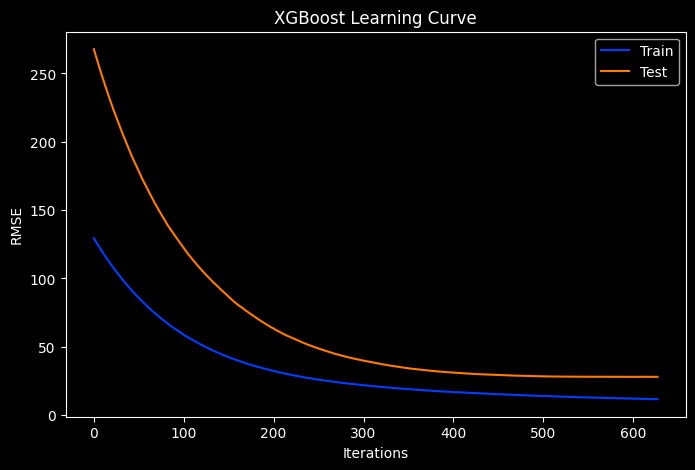

In [11]:
#  Create a dict to store evals results
evals_result = {}

xgb_model_native = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=50,
    evals_result=evals_result   # <- pass the dict here
)

#  Now evals_result dict contains train/validation RMSE
plt.figure(figsize=(8,5))
plt.plot(evals_result['train']['rmse'], label='Train')
plt.plot(evals_result['eval']['rmse'], label='Test')
plt.title("XGBoost Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.show()




In [12]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=3,
    min_child_samples=20,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric="rmse",
    callbacks=[lgb.log_evaluation(0), lgb.early_stopping(50)]
)

lgb_metrics = evaluate_model(lgb_model, X_train, y_train, X_test, y_test)
lgb_metrics

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9502
[LightGBM] [Info] Number of data points in the train set: 4316, number of used features: 59
[LightGBM] [Info] Start training from score 187.290168
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

{'Train RMSE': np.float64(15.957201750990347),
 'Test RMSE': np.float64(26.76524958417116),
 'Test MAE': 14.687066314420484,
 'Test R2': 0.9758776842715491,
 'Test MAPE': np.float64(3.0595022762909063)}

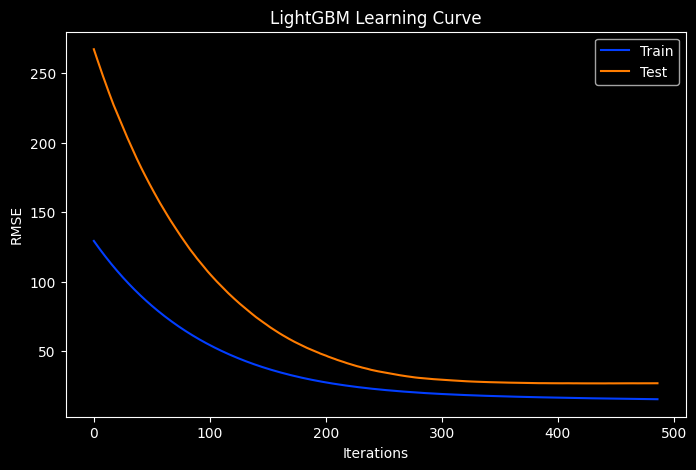

In [13]:
evals_result = lgb_model.evals_result_

plt.figure(figsize=(8,5))
plt.plot(evals_result['training']['rmse'], label='Train')
plt.plot(evals_result['valid_1']['rmse'],  label='Test')
plt.title("LightGBM Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [14]:
cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.02,
    depth=5,
    l2_leaf_reg=12,
    random_seed=42,
    od_type='Iter',
    od_wait=50,
    verbose=False
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=False
)

cat_metrics = evaluate_model(cat_model, X_train, y_train, X_test, y_test)
cat_metrics


{'Train RMSE': np.float64(4.145955812468181),
 'Test RMSE': np.float64(25.53814321701744),
 'Test MAE': 13.230521154316014,
 'Test R2': 0.9780388519983985,
 'Test MAPE': np.float64(2.9062780844036973)}

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator

tscv_cv = TimeSeriesSplit(n_splits=10)

# LightGBM CV
lgb_cv_scores = cross_val_score(
    lgb_model, X, y,
    cv=tscv_cv,
    scoring="neg_root_mean_squared_error"
)

# CatBoost CV
cat_cv_scores = cross_val_score(
    cat_model, X, y,
    cv=tscv_cv,
    scoring="neg_root_mean_squared_error"
)

print("LightGBM  — Mean CV RMSE:", round(-lgb_cv_scores.mean(), 4), "| Std:", round(lgb_cv_scores.std(), 4))
print("CatBoost  — Mean CV RMSE:", round(-cat_cv_scores.mean(), 4), "| Std:", round(cat_cv_scores.std(), 4))

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [16]:
print("LightGBM best iteration:", lgb_model.best_iteration_)
print("CatBoost best iteration:", cat_model.best_iteration_)

LightGBM best iteration: 437
CatBoost best iteration: 1999


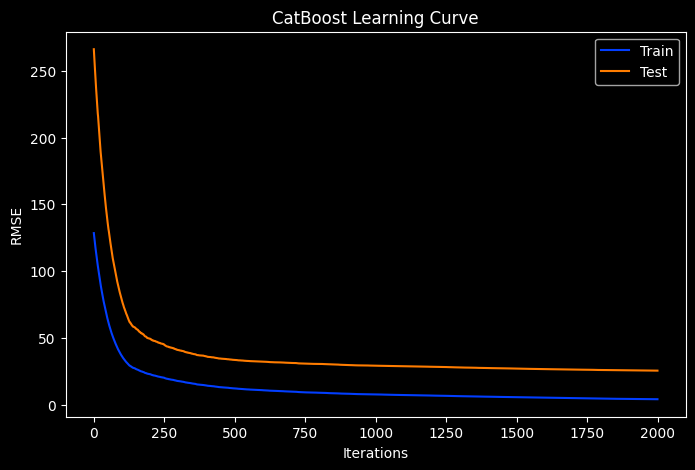

In [17]:
results = cat_model.get_evals_result()

plt.figure(figsize=(8,5))
plt.plot(results['learn']['RMSE'], label='Train')
plt.plot(results['validation']['RMSE'], label='Test')
plt.title("CatBoost Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.show()


In [18]:
comparison = pd.DataFrame([xgb_metrics, lgb_metrics, cat_metrics],
                          index=["XGBoost", "LightGBM", "CatBoost"])

comparison.sort_values("Test RMSE")


,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE
CatBoost,4.145956,25.538143,13.230521,0.978039,2.906278
LightGBM,15.957202,26.765250,14.687066,0.975878,3.059502
XGBoost,11.650580,28.050092,15.661031,0.973506,3.415269


In [19]:
import joblib
import os

# Create a folder to save models
os.makedirs("/content/baseline_models", exist_ok=True)

# Save LightGBM
joblib.dump(lgb_model, "/content/baseline_models/lgb_baseline-new.pkl")

# Save CatBoost
joblib.dump(cat_model, "/content/baseline_models/cat_baseline-new.pkl")

# Save XGBoost (native booster uses its own save method)
xgb_model_native.save_model("/content/baseline_models/xgb_baseline-new.json")

print("All baseline models saved:")
print("  /content/baseline_models/lgb_baseline.pkl")
print("  /content/baseline_models/cat_baseline.pkl")
print("  /content/baseline_models/xgb_baseline.json")

All baseline models saved:
  /content/baseline_models/lgb_baseline.pkl
  /content/baseline_models/cat_baseline.pkl
  /content/baseline_models/xgb_baseline.json


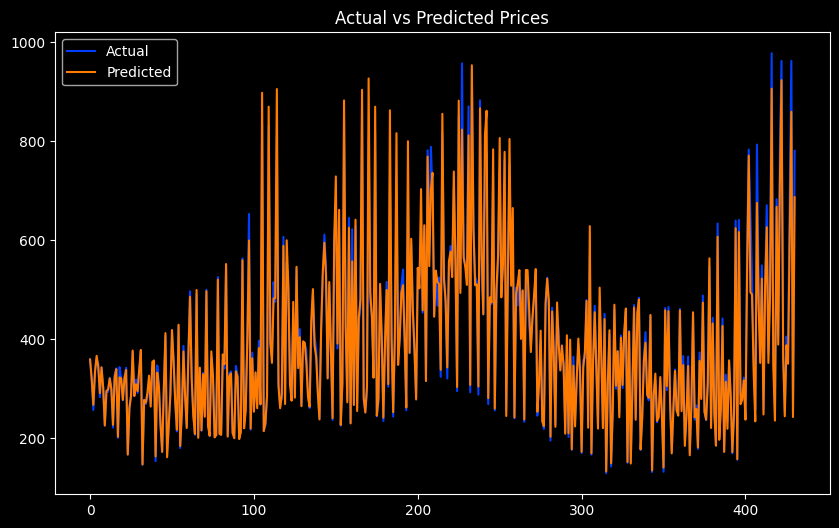

In [20]:
best_model = lgb_model

y_pred = best_model.predict(X_test)

plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()


In [21]:
best_per_metric = comparison.idxmin()  # for RMSE, MAE, MAPE lower is better
best_per_metric['Test R2'] = comparison['Test R2'].idxmax()  # for R2, higher is better

best_per_metric


,0
Train RMSE,CatBoost
Test RMSE,CatBoost
Test MAE,CatBoost
Test R2,CatBoost
Test MAPE,CatBoost


In [22]:
ranks = comparison.rank(axis=0, ascending=[True, True, True, False])
avg_rank = ranks.mean(axis=1)
best_overall = avg_rank.idxmin()
best_overall



'CatBoost'